# 03b · Build the whole thing, from scratch — one file, no helpers

You've built every piece of a DDPM across notebooks 01–03 with the `nanodiffusion`
package holding your hand. **This is the final test: build the entire model
yourself, in one self-contained file — pure `torch` / `numpy` / `matplotlib`, not a
single `nanodiffusion` import.**

And we drop the swiss roll for a **heart** 🖤 — a shape the model never saw in
01–03 — to prove the code is distribution-agnostic: the same lines learn *anything*.

> 📝 **Six `# TODO`s.** The markdown above each one **reminds the theory** — the
> equation and the shapes you need — but the code cells are yours to write from
> scratch; nothing is given away. Each TODO is followed by a self-check that prints
> ✅. Stuck? The answer key is `solutions/notebooks/03b_...`.

## 0 · Imports and device

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

def pick_device():
    if torch.cuda.is_available(): return torch.device("cuda")
    if torch.backends.mps.is_available(): return torch.device("mps")
    return torch.device("cpu")

device = pick_device()
torch.manual_seed(0); np.random.seed(0)
print("device:", device)

device: mps


## 1 · The data — a 2D heart  *(given)*

Data generation isn't the diffusion part, so this one's free. `heart` rejection-
samples the classic heart inequality; `points_from_text` turns any word into a
point cloud so you can generate your own shapes.

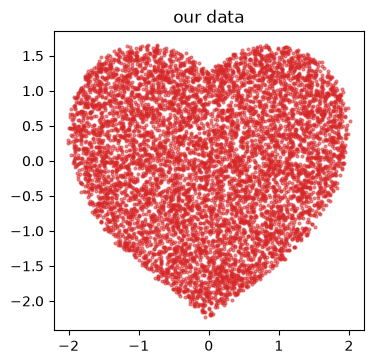

In [2]:
def heart(n):
    pts = []
    while len(pts) < n:                                  # rejection sampling
        xy = np.random.uniform(-1.5, 1.5, (4 * n, 2))
        x, y = xy[:, 0], xy[:, 1]
        inside = (x**2 + y**2 - 1) ** 3 - x**2 * y**3 < 0
        pts.extend(xy[inside].tolist())
    pts = np.array(pts[:n]) + 0.01 * np.random.randn(n, 2)
    pts = (pts - pts.mean(0)) / (pts.std() + 1e-8)
    return torch.from_numpy(pts.astype(np.float32))

def points_from_text(text, n, fontsize=180):
    fig = plt.figure(figsize=(4, 2), dpi=100)
    fig.text(0.5, 0.5, text, fontsize=fontsize, ha="center", va="center")
    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8).reshape(h, w, 4)
    plt.close(fig)
    ys, xs = np.where(buf[:, :, :3].mean(2) < 128)
    idx = np.random.choice(len(xs), n, replace=len(xs) < n)
    pts = np.stack([xs[idx], h - ys[idx]], 1).astype(np.float32) + 0.6 * np.random.randn(n, 2)
    pts = (pts - pts.mean(0)) / (pts.std() + 1e-8)
    return torch.from_numpy(pts.astype(np.float32))

data = heart(8000).to(device)      # 🔬 try: points_from_text("nano", 8000)  or  points_from_text("π", 8000)

d = data.cpu()
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(d[:, 0], d[:, 1], s=4, alpha=0.5, color="C3")
ax.set_aspect("equal"); ax.set_title("our data"); plt.show()

> **🔬 Explore.** Nothing below ever mentions "heart" — the model works on whatever
> `data` is. After it all runs, swap `heart(8000)` for `points_from_text("nano", 8000)`
> and **restart & run all** to generate that shape from noise.

## 2 · TODO — the noise schedule

**Reminder (notebook 01).** The cosine schedule specifies the surviving-signal curve
$\bar\alpha_t$ *directly* as a cosine of the fraction $t/T$, then reads the per-step
noise variances back out:

$$\bar\alpha_t=\frac{f(t)}{f(0)},\quad f(u)=\cos\!\Big(\frac{u/T+s}{1+s}\cdot\frac{\pi}{2}\Big)^{2}\ \ (s=0.008),\qquad \beta_t=1-\frac{\bar\alpha_t}{\bar\alpha_{t-1}}.$$

Build a length-$(T{+}1)$ grid $u=0,\dots,T$, evaluate $f$ and normalize by $f(0)$,
then form the $T$ betas from the consecutive ratios. **Clamp** the betas into
$[10^{-8},\,0.999]$ so the terminal step stays numerically safe. The mechanical
derivations ($\alpha_t,\ \bar\alpha_t,\ \bar\alpha_{t-1}$) are given below the stub.

In [3]:
T = 200

def cosine_betas(T, s=0.008):
    '''Return the T betas of the cosine schedule (see the equations above).'''
    u = torch.linspace(0, T, T + 1)
    ab = torch.cos(((u / T + s) / (1 + s)) * math.pi / 2) ** 2
    ab = ab / ab[0]
    return (1 - ab[1:] / ab[:-1]).clamp(1e-8, 0.999)

betas = cosine_betas(T).to(device)
alphas = 1.0 - betas                                     # given: the mechanical derivations
alpha_bars = torch.cumprod(alphas, dim=0)
alpha_bars_prev = torch.cat([torch.ones(1, device=device), alpha_bars[:-1]])

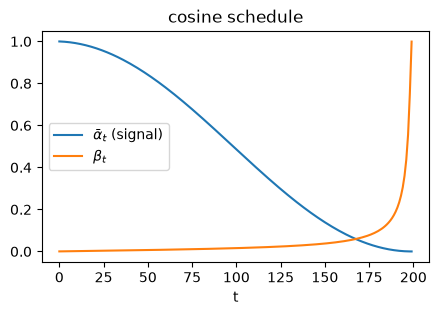

✅ schedule ok — alpha_bar_T = 6.07e-08


In [4]:
# ---- check: schedule ----
assert torch.all(alpha_bars[:-1] >= alpha_bars[1:]), "alpha_bar must be non-increasing"
assert alpha_bars[-1] < 0.01, "the schedule should reach ~pure noise by t=T"
plt.figure(figsize=(5, 3))
plt.plot(alpha_bars.cpu(), label=r"$\bar\alpha_t$ (signal)"); plt.plot(betas.cpu(), label=r"$\beta_t$")
plt.xlabel("t"); plt.legend(); plt.title("cosine schedule"); plt.show()
print(f"✅ schedule ok — alpha_bar_T = {alpha_bars[-1]:.2e}")

## 3 · TODO — the forward process

**Reminder — the "nice property" (notebook 01).** Noise a clean point to *any*
timestep in a single shot:

$$x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\varepsilon,\qquad \varepsilon\sim\mathcal N(0,I).$$

**Shape note.** `x0` is $(B,2)$ and `t` is $(B,)$, so `alpha_bars[t]` is $(B,)$ —
reshape it to $(B,1)$ before multiplying so it broadcasts across both coordinates.
`noise` is passed in (same shape as `x0`).

In [5]:
def add_noise(x0, t, noise):
    '''Return x_t: noise x0 to timestep t in one shot (the nice property above).'''
    ab = alpha_bars[t].reshape(-1, 1)
    return ab.sqrt() * x0 + (1 - ab).sqrt() * noise

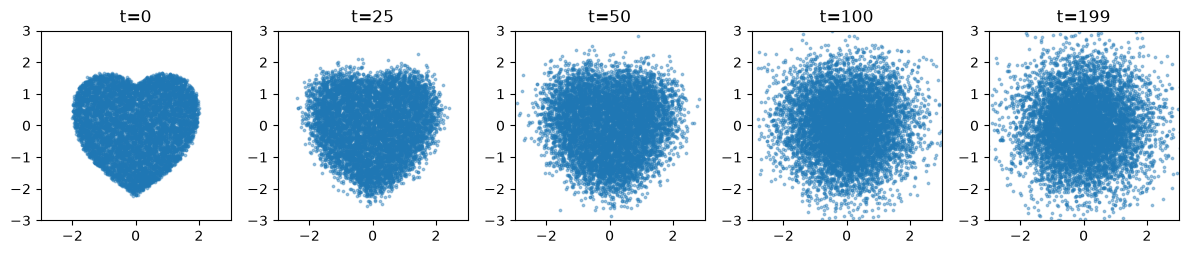

✅ forward process ok — the heart dissolves into noise


In [6]:
# ---- check: forward process ----
x_T = add_noise(data, torch.full((data.shape[0],), T - 1, device=device), torch.randn_like(data))
assert x_T.shape == data.shape, "wrong shape"
assert abs(x_T.std().item() - 1.0) < 0.15, "x_T should be ~unit-variance noise"
ts = [0, 25, 50, 100, 199]
fig, axes = plt.subplots(1, len(ts), figsize=(2.4 * len(ts), 2.4))
for ax, ti in zip(axes, ts):
    xt = add_noise(data, torch.full((data.shape[0],), ti, device=device), torch.randn_like(data)).cpu()
    ax.scatter(xt[:, 0], xt[:, 1], s=3, alpha=0.4); ax.set_title(f"t={ti}")
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect("equal")
plt.tight_layout(); plt.show()
print("✅ forward process ok — the heart dissolves into noise")

## 4 · TODO — the network

The `__init__`s (architecture) are given. Implement the two `forward` methods.

**Time embedding (notebook 02).** With embedding dim $d$ and $\text{half}=d/2$, use
geometrically-spaced frequencies $\omega_i=10000^{-\,i/(\text{half}-1)}$ and return

$$\text{emb}(t)=\big[\sin(t\,\omega_0),\dots,\sin(t\,\omega_{\text{half}-1}),\ \cos(t\,\omega_0),\dots,\cos(t\,\omega_{\text{half}-1})\big]\in\mathbb R^{B\times d}.$$

(The "bank of clocks": fast frequencies separate adjacent $t$, slow ones separate
early from late.)

**Denoiser.** Embed $t$ with `self.time_mlp`, **concatenate** that onto `x` along the
last dimension, and run the result through `self.net` to get the predicted noise
$(B,2)$.

In [7]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__(); self.dim = dim
    def forward(self, t):
        '''(B,) timesteps -> (B, dim) embedding (see the formula above).'''
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000.0) * torch.arange(half, device=t.device) / (half - 1))
        args = t.float()[:, None] * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

class MLPDenoiser(nn.Module):
    def __init__(self, data_dim=2, hidden=128, depth=4, time_dim=64):
        super().__init__()
        self.time_mlp = nn.Sequential(SinusoidalTimeEmbedding(time_dim),
                                      nn.Linear(time_dim, time_dim), nn.SiLU())
        layers = [nn.Linear(data_dim + time_dim, hidden), nn.SiLU()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.SiLU()]
        layers += [nn.Linear(hidden, data_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x, t):
        '''Predict the noise in x at timesteps t (see above).  x:(B,2) t:(B,) -> (B,2)'''
        return self.net(torch.cat([x, self.time_mlp(t)], dim=-1))

In [8]:
# ---- check: model ----
probe = MLPDenoiser().to(device)
out = probe(data[:8], torch.randint(0, T, (8,), device=device))
assert out.shape == (8, 2) and out.requires_grad, "output should be (8,2) and differentiable"
print(f"✅ model ok — {sum(p.numel() for p in probe.parameters()):,} parameters")

✅ model ok — 62,530 parameters


## 5 · TODO — the loss and the training loop

**The DDPM loss (notebook 02).** The whole objective is a mean-squared error on the
noise:

$$L=\mathbb E_{x_0,\,t,\,\varepsilon}\big[\lVert\varepsilon-\varepsilon_\theta(x_t,t)\rVert^2\big].$$

For a clean batch `x0`: draw one random timestep per item
($t\sim\text{Uniform}\{0,\dots,T-1\}$), draw $\varepsilon\sim\mathcal N(0,I)$, form
$x_t$ with `add_noise`, predict $\varepsilon_\theta$, and return the MSE between the
prediction and $\varepsilon$.

**The training loop.** Standard PyTorch. Each step: sample a minibatch of 512 point
indices into `data`, compute the loss, then `zero_grad → backward → step` (gradients
*accumulate*, so zero them first), and append `loss.item()` to `losses`.

In [9]:
def ddpm_loss(model, x0):
    '''The DDPM epsilon-prediction MSE loss for a clean batch x0 (see above).'''
    t = torch.randint(0, T, (x0.shape[0],), device=device)
    noise = torch.randn_like(x0)
    x_t = add_noise(x0, t, noise)
    return F.mse_loss(model(x_t, t), noise)

In [10]:
torch.manual_seed(0)
model = MLPDenoiser().to(device)
opt = torch.optim.Adam(model.parameters(), lr=2e-3)

losses = []
for step in range(3000):
    idx = torch.randint(0, data.shape[0], (512,), device=device)
    loss = ddpm_loss(model, data[idx])
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
    if step % 500 == 0:
        print(f"step {step:4d}   loss {loss.item():.4f}")

step    0   loss 1.0229


step  500   loss 0.4144


step 1000   loss 0.4615


step 1500   loss 0.4545


step 2000   loss 0.4857


step 2500   loss 0.4956


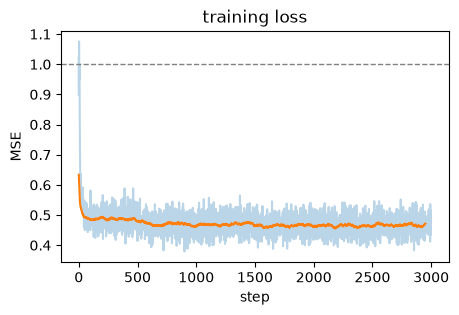

✅ trained — mean last-100 loss 0.4679


In [11]:
# ---- check: training ----
plt.figure(figsize=(5, 3))
plt.plot(losses, alpha=0.3)
plt.plot(torch.tensor(losses).unfold(0, 50, 1).mean(1), color="C1")
plt.axhline(1.0, ls="--", c="gray", lw=1); plt.xlabel("step"); plt.ylabel("MSE")
plt.title("training loss"); plt.show()
tail = sum(losses[-100:]) / 100
assert tail < 0.6, "loss should settle well below 0.6 — check the loss and the loop"
print(f"✅ trained — mean last-100 loss {tail:.4f}")

## 6 · TODO — the sampler, and the payoff

**The reverse step (notebook 03).** Turn the predicted noise into one denoising step.
The mean and the posterior variance are

$$\mu_\theta=\frac{1}{\sqrt{\alpha_t}}\Big(x_t-\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\varepsilon_\theta\Big),\qquad \tilde\beta_t=\beta_t\,\frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t},$$

and a full step draws

$$x_{t-1}=\mu_\theta+\sqrt{\tilde\beta_t}\,z,\quad z\sim\mathcal N(0,I),$$

with **no** noise added on the final step ($t=0$: just return the mean). Start from
$x_T\sim\mathcal N(0,I)$ and walk $t$ from $T-1$ down to $0$. The loop scaffold and
`eps = model(x, t)` are given — you write the update to `x`.

In [12]:
@torch.no_grad()
def sample(model, n, return_traj=False):
    x = torch.randn(n, 2, device=device)                 # start from x_T ~ N(0, I)
    traj = [x.clone()]
    for step in reversed(range(T)):
        t = torch.full((n,), step, device=device, dtype=torch.long)
        eps = model(x, t)                                # predicted noise
        beta_t, alpha_t = betas[step], alphas[step]
        mean = (x - beta_t / (1 - alpha_bars[step]).sqrt() * eps) / alpha_t.sqrt()
        if step > 0:
            var = beta_t * (1 - alpha_bars_prev[step]) / (1 - alpha_bars[step])
            x = mean + var.sqrt() * torch.randn_like(x)
        else:
            x = mean
        if return_traj: traj.append(x.clone())
    return (x, traj) if return_traj else x

mean nearest-neighbor distance gen→data: 0.021  (small = shape learned)


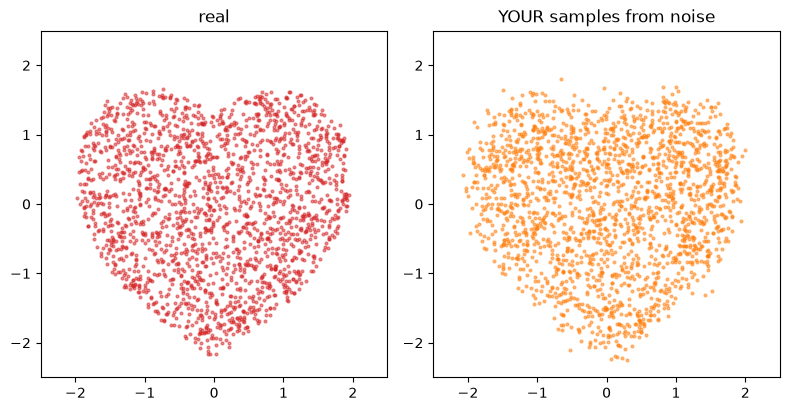

🎉 ✅ you built a diffusion model from scratch — it generates the shape from pure noise


In [13]:
# ---- check: sampling (the whole pipeline!) ----
gen = sample(model, 2000)
assert torch.isfinite(gen).all(), "produced NaN/inf — check the mean formula"
nn_dist = torch.cdist(gen, data).min(1).values.mean().item()
print(f"mean nearest-neighbor distance gen→data: {nn_dist:.3f}  (small = shape learned)")
assert nn_dist < 0.15, "generated points should land on the shape"

g, r = gen.cpu(), data[:2000].cpu()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8, 4))
a1.scatter(r[:, 0], r[:, 1], s=4, alpha=0.5, color="C3"); a1.set_title("real")
a2.scatter(g[:, 0], g[:, 1], s=4, alpha=0.5, color="C1"); a2.set_title("YOUR samples from noise")
for a in (a1, a2): a.set_aspect("equal"); a.set_xlim(-2.5, 2.5); a.set_ylim(-2.5, 2.5)
plt.tight_layout(); plt.show()
print("🎉 ✅ you built a diffusion model from scratch — it generates the shape from pure noise")

## 7 · Watch it reform

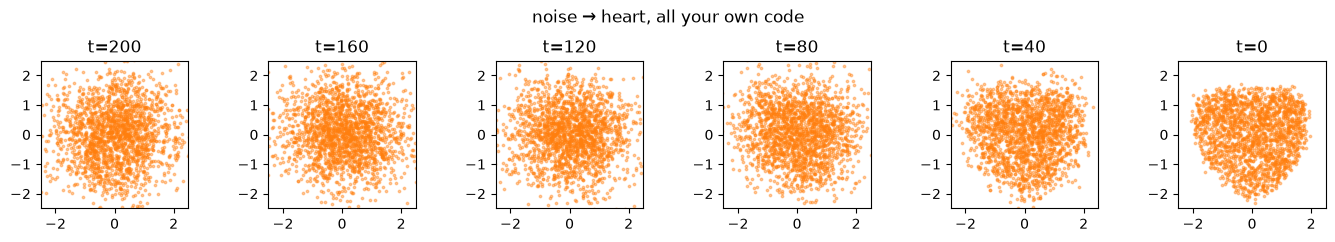

In [14]:
_, traj = sample(model, 2000, return_traj=True)
picks = [0, 40, 80, 120, 160, 200]
fig, axes = plt.subplots(1, len(picks), figsize=(2.3 * len(picks), 2.3))
for ax, i in zip(axes, picks):
    p = traj[i].cpu()
    ax.scatter(p[:, 0], p[:, 1], s=3, alpha=0.4, color="C1")
    ax.set_title(f"t={max(T - i, 0)}"); ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5); ax.set_aspect("equal")
plt.suptitle("noise → heart, all your own code"); plt.tight_layout(); plt.show()

## 🎉 You built a diffusion model — the whole thing, yourself

Everything between the imports and here — schedule, forward process, network, loss,
training, sampler — is **~130 lines of plain PyTorch you wrote**, no library doing
the diffusion for you, and it just conjured a **heart** from static.

**What changes for real images (Part 2):** almost nothing in this structure — the
forward process, loss, and sampler stay identical. The one real swap is the
**network**: an MLP can't see spatial structure, so we replace it with a **U-Net**.
That's notebook 04.